# Find an explanatory signaling network in the Sachs data

How might the measured signals in a cell be related, and how do they respond
when a signaling molecule is perturbed? In this tutorial, we use
`LinearDAGDiscovery` to fit a small network to single-cell measurements from
the Sachs study. Sachs and colleagues used Bayesian networks; here we use a
linear model. An arrow from one signal to another means that the first
signal helps explain the second in the fitted linear model.

The study used human primary CD4+ T cells. Across experimental conditions,
researchers stimulated the cells through CD3 and CD28, sometimes added
ICAM-2, or applied compounds that perturb signaling. After 15 minutes,
they measured 11 protein and phospholipid signals in individual cells by
flow cytometry, a technique that records several signals per cell.

The original study called CD3/CD28 and ICAM-2 **general perturbations**.
In this tutorial, their two conditions are **observational with respect
to the 11 measured signals**: the cells were stimulated, but no measured
signal was directly targeted. The **intervention conditions** use more
specific treatments with an annotated target. Together, these conditions
show how the signals vary and respond to targeted treatments.

We will load the cell measurements, mark the intervention targets, fit a
network, and read its selected arrows. We will then try a second way to model
the interventions. The
[LinearDAGDiscovery guide](../../guide/causal/linear-dag-discovery.ipynb)
explains the method and additional modeling options.

Data: [Sachs Zenodo record](https://zenodo.org/records/7681811).
Original study: [Sachs and colleagues (2005)](https://doi.org/10.1126/science.1105809).

In [1]:
from pathlib import Path

from IPython.display import display
import numpy as np
import pandas as pd

import corneto as cn
from corneto.backend import CvxpyBackend
from corneto.data import Data
from corneto.datasets import fetch_dataset
from corneto.methods import LinearDAGDiscovery

DATASET_DIR = fetch_dataset("sachs")
DATASET_PATH = DATASET_DIR / "measurements.tsv"
CONDITION_MANIFEST_PATH = DATASET_DIR / "condition_manifest.csv"
NODE_COLUMNS = [
    "raf", "mek", "plc", "pip2", "pip3", "erk",
    "akt", "pka", "pkc", "p38", "jnk",
]
# Use 100 cells per condition for a quicker run; use None for all cells.
SAMPLES_PER_CONDITION: int | None = 100
MIN_ABS_COEFFICIENT = 0.25
SEED = 7
SOLVE_SECONDS = 300
LAMBDA_UNEXPLAINED = 1.0


## 1. Load and inspect the measurements

Each row in the Sachs data represents one cell. The columns below record the
signals measured in that cell. Most protein measurements indicate
phosphorylation, a chemical change commonly used to track signaling
activity. PIP2 and PIP3 are signaling lipids. The values have already
been transformed with the natural logarithm.

| Column | Biological measurement |
| --- | --- |
| `raf` | phosphorylated Raf |
| `mek` | phosphorylated MEK1/2 |
| `plc` | phosphorylated PLCγ |
| `pip2` | PIP2 abundance |
| `pip3` | PIP3 abundance |
| `erk` | phosphorylated ERK1/2 |
| `akt` | phosphorylated Akt |
| `pka` | PKA-substrate phosphorylation signal |
| `pkc` | phosphorylated PKC |
| `p38` | phosphorylated p38 |
| `jnk` | phosphorylated JNK |

The measurement file contains these 11 signals for each cell. A separate
condition manifest names the treatment and, when applicable, the measured
signal treated as its direct target. The next cell joins the two files and
shows the first few rows of the resulting data frame.

In [2]:
def load_sachs_dataframe(path: Path, manifest_path: Path) -> pd.DataFrame:
    measurements = pd.read_csv(path, sep="\t")
    manifest = pd.read_csv(manifest_path)
    blocks = []
    cursor = 0
    for row in manifest.itertuples(index=False):
        if row.start_row != cursor or row.stop_row <= cursor:
            raise ValueError("Sachs condition rows must be contiguous.")
        block = measurements.iloc[row.start_row:row.stop_row].copy()
        if not block["intervention_label"].eq(row.archive_label).all():
            raise ValueError(f"Unexpected archive label for {row.condition}.")
        block.insert(1, "condition", row.condition)
        block.insert(
            2,
            "intervention_target",
            row.intervention_target if pd.notna(row.intervention_target) else None,
        )
        blocks.append(block)
        cursor = row.stop_row
    if cursor != len(measurements):
        raise ValueError("The condition manifest does not cover every cell.")
    return pd.concat(blocks, ignore_index=True)


raw = load_sachs_dataframe(DATASET_PATH, CONDITION_MANIFEST_PATH)
raw[["condition", "intervention_label", "intervention_target", "raf", "mek", "akt"]].head(8).round(2)

,condition,intervention_label,intervention_target,raf,mek,akt
0,cd3cd28,observational,None,3.27,2.58,2.83
1,cd3cd28,observational,None,3.58,2.80,3.48
2,cd3cd28,observational,None,4.08,3.79,3.48
3,cd3cd28,observational,None,4.29,4.42,2.47
4,cd3cd28,observational,None,3.52,2.99,3.83
5,cd3cd28,observational,None,2.93,1.32,3.25
6,cd3cd28,observational,None,3.80,3.60,2.88
7,cd3cd28,observational,None,3.86,2.71,3.81


The first rows come from the CD3/CD28 condition, which has no annotated
direct target among the measured signals. `condition` names the treatment,
and `intervention_target` gives its measured target when there is one.
The archive's `intervention_label` sometimes names a different signal, so
the model uses the target supplied by the condition manifest.

## 2. Choose cells for the analysis

The full file has 7,466 cells across nine conditions. We leave out the
LY294002 condition because it targets PI3K, which is absent from the
11 measured signals. This leaves 6,618 cells in eight conditions.

To keep the fitting time manageable, we select 100 cells from each
remaining condition. The next table shows the direct target, number
of available cells, and number selected for each condition.

In [3]:
analysis_raw = raw.loc[raw["condition"] != "cd3cd28_ly"].copy()


def stratified_subsample(
    frame: pd.DataFrame,
    samples_per_condition: int | None,
    seed: int,
) -> pd.DataFrame:
    """Keep all rows or take a reproducible sample from each condition."""
    if samples_per_condition is None:
        return frame.copy().reset_index(drop=True)
    if samples_per_condition <= 0:
        raise ValueError("samples_per_condition must be positive or None")
    rng = np.random.default_rng(seed)
    selected = []
    for condition, group in frame.groupby("condition", sort=True):
        if len(group) > samples_per_condition:
            indices = rng.choice(group.index.to_numpy(), size=samples_per_condition, replace=False)
            group = group.loc[np.sort(indices)]
        selected.append(group.copy())
    return pd.concat(selected, ignore_index=True)


sampled = stratified_subsample(analysis_raw, samples_per_condition=SAMPLES_PER_CONDITION, seed=SEED)
condition_summary = raw.groupby("condition", sort=False).agg(
    target=("intervention_target", "first"),
    available_cells=("condition", "size"),
)
condition_summary["selected_cells"] = sampled.groupby("condition").size()
condition_summary["selected_cells"] = condition_summary["selected_cells"].fillna(0).astype(int)
condition_summary["target"] = condition_summary["target"].fillna("—")
condition_summary

,target,available_cells,selected_cells
condition,,,
cd3cd28,—,853,100
cd3cd28_icam2,—,902,100
cd3cd28_aktinhib,akt,911,100
cd3cd28_g0076,pkc,723,100
cd3cd28_psitect,pip2,810,100
cd3cd28_u0126,mek,799,100
cd3cd28_ly,—,848,0
pma,pkc,913,100
b2camp,pka,707,100


A dash in the target column means the condition has no annotated direct
target among the measured signals. The two general-stimulation conditions
contribute 200 cells; the six targeted-treatment conditions contribute
600. Each selected cell remains a separate observation. Set
`SAMPLES_PER_CONDITION=None` to use all 6,618 retained cells.

## 3. Describe possible connections and interventions

The Sachs pathway diagram also shows CD3, CD28, ZAP70, PI3K, and other
components absent from these measurements. Here we model the 11 measured
signals: `LinearDAGDiscovery` requires observations for every graph vertex.
An inferred arrow can therefore summarize a path through unmeasured
components.

Before fitting, we give CORNETO a set of possible arrows between the
measured signals. For this example, we allow an arrow between every
pair of different signals, in either direction: 110 candidates. The
optimizer will select a smaller set without loops that lead back to
a starting signal. An interaction value of `0` leaves each arrow's
sign open to be learned from the measurements.

We then turn each cell into a CORNETO sample. Its 11 measured values
map to the 11 graph vertices. For a treated cell, we mark the directly
targeted signal with `intervention="hard"`. The fit uses its measured
value when explaining other signals and skips the target's own equation.
Cells receiving the same treatment share an `intervention_group`, while
each cell keeps its own measurements. See the guide's
{ref}`intervention metadata table <linear-dag-intervention-metadata>`
for the accepted fields and the alternative shift intervention.

In [4]:
prior_edges = [
    (source, 0, target)
    for source in NODE_COLUMNS
    for target in NODE_COLUMNS
    if source != target
]
prior = cn.Graph.from_tuples(prior_edges)

In [5]:
def to_corneto_data(frame: pd.DataFrame, intervention_mode: str = "hard") -> Data:
    if intervention_mode not in {"hard", "shift"}:
        raise ValueError("intervention_mode must be 'hard' or 'shift'")
    samples = {}
    for sample_index, row in frame.iterrows():
        condition = str(row["condition"])
        target = row["intervention_target"]
        sample_name = f"sachs_{sample_index:04d}_{condition}"
        samples[sample_name] = {}
        for node in NODE_COLUMNS:
            feature = {"mapping": "vertex", "value": float(row[node])}
            if pd.notna(target) and node == target:
                feature["intervention"] = intervention_mode
                feature["intervention_group"] = condition
            samples[sample_name][node] = feature
    return Data.from_cdict(samples)


data = to_corneto_data(sampled)
targeted_cells = sampled.loc[sampled["intervention_target"].notna()]
pd.Series(
    {
        "measured signals": prior.num_vertices,
        "candidate arrows": prior.num_edges,
        "cells used": len(data.samples),
        "targeted conditions": targeted_cells["condition"].nunique(),
    },
    name="value",
)

measured signals        11
candidate arrows       110
cells used             800
targeted conditions      6
Name: value, dtype: int64

## 4. Fit the network

The model predicts each signal from a weighted sum of signals with
arrows pointing to it. We favor fewer arrows, allow at most three
arrows into each signal, and require selected arrows to have a
normalized coefficient of at least `0.25`. We also favor connections
from treated targets to measured responses. The guide explains these
{ref}`model choices <linear-dag-model-choices>` in detail.

This example uses GUROBI with a 300-second time limit. The result
shows how many arrows were selected and the solver status. A status of
`user_limit` means the time limit was reached; the selected network
may improve with more solve time.

The {ref}`guide's prediction workflow <linear-dag-prediction>` shows how
to assess a fitted model on held-out cells or conditions.

In [6]:
def selected_edge_count(problem) -> int | None:
    values = problem.expr.edge_selected.value
    if values is None:
        return None
    return int((np.asarray(values).reshape(-1) > 0.5).sum())


def require_usable_solution(problem, solved) -> None:
    if solved.value is None or not np.isfinite(solved.value):
        raise RuntimeError(f"The solver returned no usable solution ({solved.status}).")
    if problem.expr.edge_selected.value is None:
        raise RuntimeError(f"The solver returned no edge-selection values ({solved.status}).")


def fit_summary(label: str, problem, solved) -> dict:
    return {
        "intervention model": label,
        "solver status": str(solved.status),
        "selected arrows": selected_edge_count(problem),
        "solve time (s)": getattr(solved.solver_stats, "solve_time", None),
    }


def fit_model(fit_data: Data, **method_options):
    method = LinearDAGDiscovery(
        lambda_edges=0.03,
        max_parents=3,
        min_abs_coefficient=MIN_ABS_COEFFICIENT,
        lambda_unexplained=LAMBDA_UNEXPLAINED,
        backend=CvxpyBackend(),
        **method_options,
    )
    problem = method.build(prior, fit_data)
    solved = problem.solve(
        solver="GUROBI",
        max_seconds=SOLVE_SECONDS,
        verbosity=0,
        IntegralityFocus=1,
    )
    require_usable_solution(problem, solved)
    return method, problem, solved


exact_method, exact_problem, exact_solved = fit_model(data)
hard_fit_summary = pd.DataFrame([fit_summary("hard", exact_problem, exact_solved)])
hard_fit_summary

,intervention model,solver status,selected arrows,solve time (s)
0,hard,user_limit,22,300.045893


## 5. Examine the selected arrows

Each row of the table below is an arrow in the fitted network.
`coefficient` tells us how much the model's predicted target signal
changes when its source signal increases by one unit, with the other
selected inputs held fixed. `normalized_coefficient` rescales that
slope so the `0.25` threshold can be applied across signal pairs.
The `sign` column summarizes whether the fitted relationship is
positive or negative. The guide explains the remaining
{ref}`edge fields <linear-dag-edge-metadata>`.

In [7]:
def solution_edge_table(method) -> pd.DataFrame:
    graph = method.get_solution_graph()
    rows = []
    for edge_index, (source_set, target_set) in enumerate(graph.E):
        attributes = graph.get_attr_edge(edge_index)
        rows.append(
            {
                "source": next(iter(source_set)),
                "target": next(iter(target_set)),
                "coefficient": attributes["coefficient"],
                "normalized_coefficient": attributes["normalized_coefficient"],
                "sign": "positive" if attributes["coefficient"] > 0 else "negative",
            }
        )
    columns = ["source", "target", "coefficient", "normalized_coefficient", "sign"]
    result = pd.DataFrame(rows, columns=columns)
    if result.empty:
        return result
    return result.sort_values("normalized_coefficient", key=np.abs, ascending=False)


exact_edges = solution_edge_table(exact_method)
exact_edges

,source,target,coefficient,normalized_coefficient,sign
1,mek,raf,0.593970,0.923388,positive
11,akt,erk,0.878460,0.820500,positive
14,pkc,mek,0.807502,0.638058,positive
18,pkc,jnk,0.690871,0.608625,positive
17,pkc,p38,0.591843,0.570519,positive
19,p38,pka,-0.611769,-0.567900,negative
2,mek,erk,-0.332300,-0.546553,negative
6,mek,jnk,0.428736,0.477999,positive
4,mek,pka,-0.417555,-0.472875,negative
3,mek,akt,0.243035,0.427971,positive


The network plot makes the table easier to scan: blue arrows have positive
fitted coefficients, orange arrows have negative ones, and labels show their
coefficient values. Pick an arrow in the plot and find the same source and
target in the table. A positive coefficient means the model predicts a higher
target signal when its source is one unit higher on the log scale, with the
other selected inputs held fixed; a negative coefficient means it predicts
a lower target signal. These are slopes in the fitted equations. Biological
interpretation requires the assumptions discussed in the guide.

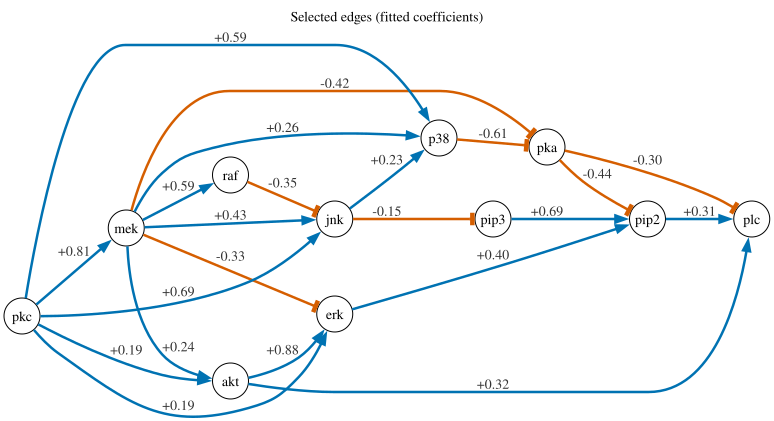

In [8]:
solution_graph = exact_method.get_solution_graph()
edge_styles = {}
for edge_index, row in exact_edges.iterrows():
    edge_styles[int(edge_index)] = {
        "color": "#0072B2" if row["coefficient"] >= 0 else "#D55E00",
        "fontcolor": "#333333",
        "label": f"{row['coefficient']:+.2f}",
        "penwidth": "2.5",
    }
assert set(edge_styles) == set(range(solution_graph.num_edges))
display(
    solution_graph.plot(
        renderer="graphviz",
        custom_edge_attr=edge_styles,
        graph_attr={"rankdir": "LR", "label": "Selected edges (fitted coefficients)", "labelloc": "t"},
    )
)


## 6. Try another intervention model

So far, we modeled each treated target as externally fixed. Here we
keep its usual equation and let the treatment add an offset. The next
cell marks those targets with `intervention="shift"` and estimates
one offset for each target and treatment condition.

The first output compares the solver status and number of selected
arrows in the two fits. The second lists the estimated offsets. A
positive offset raises the target's predicted value; a negative
offset lowers it. These values are on the log-measurement scale and
describe the fitted condition effect, not the drug dose.


In [9]:
shift_data = to_corneto_data(sampled, intervention_mode="shift")
shift_method, shift_problem, shift_solved = fit_model(
    shift_data,
    intervention_shift_bound=4.0,
    lambda_intervention_shifts=0.1,
)
shift_fit_summary = pd.DataFrame([fit_summary("additive shift", shift_problem, shift_solved)])

# The fitted offset for each treated cell is stored by vertex and sample.
shift_values = np.asarray(shift_problem.expr.intervention_shift.value)
shift_rows = []
for condition, cells in targeted_cells.groupby("condition", sort=True):
    target = cells["intervention_target"].iloc[0]
    target_index = list(prior.V).index(target)
    offsets = shift_values[target_index, cells.index.to_numpy()]
    if not np.allclose(offsets, offsets[0]):
        raise RuntimeError(f"Inconsistent fitted shifts for {condition}.")
    shift_rows.append(
        {
            "condition": condition,
            "target": target,
            "estimated log-scale shift": float(offsets[0]),
        }
    )

display(pd.concat([hard_fit_summary, shift_fit_summary], ignore_index=True))
pd.DataFrame(shift_rows)

,intervention model,solver status,selected arrows,solve time (s)
0,hard,user_limit,22,300.045893
1,additive shift,user_limit,25,300.066989


,condition,target,estimated log-scale shift
0,b2camp,pka,-2.963049
1,cd3cd28_aktinhib,akt,-0.396231
2,cd3cd28_g0076,pkc,2.058811
3,cd3cd28_psitect,pip2,-3.389326
4,cd3cd28_u0126,mek,3.518794
5,pma,pkc,0.383895


The plot below shows the network selected by the shift fit. Solid blue and
orange arrows connect measured signals; their labels are fitted
coefficients. Dashed purple arrows show the treatments. Each is labeled
with the treatment name and its learned shift, and points to the measured
target. Two treatments point to PKC because each has its own estimated
effect on that signal. The purple **Treatments** box only groups these
experimental conditions in the picture; it is not a measured signal or
a variable in the fitted network.

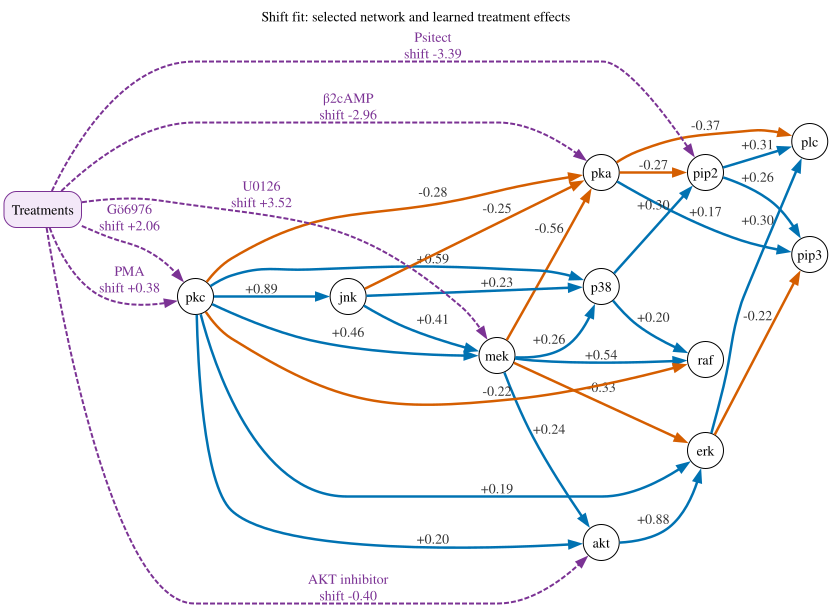

In [10]:
shift_edges = solution_edge_table(shift_method)
shift_plot = shift_method.get_solution_graph().copy()
shift_edge_styles = {}
for edge_index, row in shift_edges.iterrows():
    shift_edge_styles[int(edge_index)] = {
        "color": "#0072B2" if row["coefficient"] >= 0 else "#D55E00",
        "fontcolor": "#333333",
        "label": f"{row['coefficient']:+.2f}",
        "penwidth": "2.5",
    }

treatment_labels = {
    "b2camp": "β2cAMP",
    "cd3cd28_aktinhib": "AKT inhibitor",
    "cd3cd28_g0076": "Gö6976",
    "cd3cd28_psitect": "Psitect",
    "cd3cd28_u0126": "U0126",
    "pma": "PMA",
}
treatment_vertex = "treatment_conditions"
for row in shift_rows:
    edge_index = shift_plot.add_edge(treatment_vertex, row["target"])
    shift_edge_styles[edge_index] = {
        "color": "#7B3294",
        "fontcolor": "#7B3294",
        "style": "dashed",
        "label": f"{treatment_labels[row['condition']]}\nshift {row['estimated log-scale shift']:+.2f}",
        "penwidth": "2",
    }

display(
    shift_plot.plot(
        renderer="graphviz",
        custom_edge_attr=shift_edge_styles,
        custom_vertex_attr={
            treatment_vertex: {
                "label": "Treatments",
                "shape": "box",
                "style": "rounded,filled",
                "fillcolor": "#F3E8F8",
                "color": "#7B3294",
                "fixedsize": "false",
            }
        },
        graph_attr={"rankdir": "LR", "label": "Shift fit: selected network and learned treatment effects", "labelloc": "t"},
    )
)

## 7. Final comments

We turned single-cell measurements and treatment annotations into two
fitted networks. Their selected arrows and coefficients describe
relationships that help explain the measured signals under each model.
The dashed treatment arrows in the shift plot show estimated offsets,
not additional signaling pathways. These results provide hypotheses
about signaling rather than a verified biological pathway.

For a biological analysis, compare predictions on held-out data and repeat
the fit with different cell samples, candidate interactions, model settings,
and solve times. Then examine which arrows remain stable.